# Projeto de Classificação de Clientes

## Campanha de Marketing Bancário

**Objetivo:** Prever se um cliente bancário irá subscrever um **depósito a prazo**  com base em dados demográficos, histórico financeiro e interações de campanhas anteriores.


## Contexto do Problema de Negócio

As campanhas de marketing direto do banco baseavam-se em contatos telefônicos para a oferta de um **Depósito a Prazo** (um investimento fixo oferecido pelo banco). Frequentemente, eram necessárias múltiplas chamadas para o mesmo cliente.

* **O Desafio:** Ligar para toda a base de clientes gera custos operacionais altos e desgaste no relacionamento.
* **A Solução:** Construir um modelo preditivo de classificação para identificar o perfil de cliente propenso a aceitar a oferta, permitindo que a equipe de marketing foque apenas nos alvos de alta conversão.


## Sobre o Dataset

* **Fonte:** [OpenML - Bank Marketing (ID: 1461)](https://www.openml.org/search?type=data&status=active&sort=runs&qualities.NumberOfClasses=%3D_2&id=1461)
* **Target (y):** Indica se o cliente subscreveu o depósito a prazo (**1** = Sim, **0** = Não).
* **Desafio do Dataset:** 

    1- Desbalanceamento de classes (a maioria dos clientes declina a oferta).

    2- Erros possuem custos diferentes

    | Métrica | Situação no Banco | Impacto Financeiro / Estratégico |
    | :--- | :--- | :--- |
    | **Falso Positivo (FP)** | Ligou para quem não queria | **Baixo Custo** Custa apenas alguns euros da ligação/tempo de atendimento. |
    | **Falso Negativo (FN)** | Deixou de ligar para quem queria | **Alto Custo:** Perde-se a margem de lucro de um depósito de milhares de euros. |

## Estrutura do Projeto

1. **Análise Exploratória de Dados (EDA)**
2. **Configuração dos parâmetros e carregamento dos dados**
3. **Engenharia de variáveis**
4. **Divisão treino e teste**
5. **Pipeline de transformação**
6. **Preparação dos dados para a rede - PyTorch**
7. **Rede Neural (MLP)**
8. **Treinamento da rede neural**
9. **Avaliação do treino**
10. **Conclusões**

## 1) Análise Exploratória dos Dados 

In [53]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

marketing = fetch_openml(data_id=1461, as_frame=True, parser="auto")
X = marketing.data
y = marketing.target
df = pd.concat([X, y], axis=1)

# Renomeando as colunas 
nomes_colunas = {'V1': 'idade', 'V2': 'profissao', 'V3': 'estado_civil', 'V4': 'escolaridade', 'V5': 'inadimplente', 'V6': 'saldo', 'V7': 'emprestimo_casa', 'V8': 'emprestimo_pessoal', 
                'V9': 'tipo_contato', 'V10': 'dia', 'V11': 'mes', 'V12': 'duracao', 'V13': 'campanha', 'V14': 'pdays', 'V15': 'anteriores', 'V16': 'resultado_anterior', 'Class': 'subscreveu'}

df = df.rename(columns=nomes_colunas)

df.head()

,idade,profissao,estado_civil,escolaridade,inadimplente,saldo,emprestimo_casa,emprestimo_pessoal,tipo_contato,dia,mes,duracao,campanha,pdays,anteriores,resultado_anterior,subscreveu
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


### 1.1) Metadados 

| Variável | Nome em Português | Significado / Descrição |
| :--- | :--- | :--- |
| **idade** | Idade | Idade do cliente (em anos). |
| **profissao** | Profissão / Ocupação | Tipo de trabalho do cliente (ex: *admin.*, *blue-collar*, *technician*, *management*, etc.). |
| **estado_civil** | Estado Civil | Estado civil do cliente (*married*, *single*, *divorced* — inclui viúvos). |
| **escolaridade** | Escolaridade | Nível de instrução educacional (ex: *basic.4y*, *high.school*, *university.degree*, etc.). |
| **inadimplente** | Inadimplente | Indica se o cliente possui algum histórico de crédito em atraso/incumprimento (*yes*, *no*). |
| **saldo** | Saldo em Conta | Saldo médio anual da conta bancária do cliente (em euros). |
| **emprestimo_casa** | Empréstimo Habitacional | Indica se o cliente possui um financiamento de imóvel ativo (*yes*, *no*). |
| **emprestimo_pessoal** | Empréstimo Pessoal | Indica se o cliente possui um empréstimo pessoal ativo (*yes*, *no*). |
| **tipo_contato** | Canal de Contato | Tipo de comunicação utilizado na abordagem (*cellular*, *telephone*). |
| **dia** | Dia do Mês | Dia do mês em que foi realizado o último contato com o cliente (1 a 31). |
| **mes** | Mês | Último mês em que o cliente foi contatado no ano (*jan*, *feb*, ..., *dec*). |
| **duracao** | Duração da Ligação | Duração da última chamada telefônica (em segundos). |
| **campanha** | Contatos na Campanha | Número total de contatos/ligações realizadas para este cliente durante a campanha atual. |
| **pdays** | Dias Desde Último Contato | Número de dias após o último contato de uma campanha anterior (`-1` = nunca foi contatado antes). |
| **anteriores** | Contatos Anteriores | Número de contatos/ligações realizadas para este cliente antes desta campanha. |
| **resultado_anterior** | Resultado Anterior | Resultado da campanha de marketing anterior ao cliente (*success*, *failure*, *other*, *unknown*). |
| **subscreveu** | Subscreveu Depósito| **Variável Alvo (Target):** Indica se o cliente aceitou assinar o depósito a prazo (*yes*(2) / *no*(1)). |

In [54]:
 # Verificando se há valores ausentes 

df.isna().sum()

idade                 0
profissao             0
estado_civil          0
escolaridade          0
inadimplente          0
saldo                 0
emprestimo_casa       0
emprestimo_pessoal    0
tipo_contato          0
dia                   0
mes                   0
duracao               0
campanha              0
pdays                 0
anteriores            0
resultado_anterior    0
subscreveu            0
dtype: int64

In [55]:
# Verificando os tipos de dados

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   idade               45211 non-null  int64   
 1   profissao           45211 non-null  category
 2   estado_civil        45211 non-null  category
 3   escolaridade        45211 non-null  category
 4   inadimplente        45211 non-null  category
 5   saldo               45211 non-null  int64   
 6   emprestimo_casa     45211 non-null  category
 7   emprestimo_pessoal  45211 non-null  category
 8   tipo_contato        45211 non-null  category
 9   dia                 45211 non-null  int64   
 10  mes                 45211 non-null  category
 11  duracao             45211 non-null  int64   
 12  campanha            45211 non-null  int64   
 13  pdays               45211 non-null  int64   
 14  anteriores          45211 non-null  int64   
 15  resultado_anterior  45211 non-null  category
 1

In [56]:
# Verificando as variáveis categóricas 

var_cat = ['profissao', 'estado_civil', 'escolaridade', 'inadimplente', 'emprestimo_casa', 'emprestimo_pessoal', 'tipo_contato', 'mes', 'resultado_anterior', 'subscreveu']

for var in var_cat:
    print(55*'-')
    print(df[var].value_counts())

-------------------------------------------------------
profissao
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
-------------------------------------------------------
estado_civil
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
-------------------------------------------------------
escolaridade
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
-------------------------------------------------------
inadimplente
no     44396
yes      815
Name: count, dtype: int64
-------------------------------------------------------
emprestimo_casa
yes    25130
no     20081
Name: count, dtype: int64
-------------------------------------------------------
emprestimo_pessoal
no  

In [57]:
# Verificando as variáveis contínuas 

var_cat = ['profissao', 'estado_civil', 'escolaridade', 'inadimplente', 'emprestimo_casa', 'emprestimo_pessoal', 'tipo_contato', 'mes', 'resultado_anterior', 'subscreveu']
var_cont = df.columns.drop(var_cat)

In [58]:
df[var_cont].describe().T

,count,mean,std,min,25%,50%,75%,max
idade,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
saldo,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
dia,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duracao,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campanha,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
anteriores,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [60]:
# Verificando a variável alvo 

df['subscreveu'].value_counts(normalize=True).round(2)

subscreveu
1    0.88
2    0.12
Name: proportion, dtype: float64

In [61]:
### Tratamentos necessários 

# ['profissao', 'estado_civil', 'inadimplente', 'emprestimo_casa', 'emprestimo_pessoal', 'tipo_contato', 'resultado_anterior'] --> One-Hot Encoding 

# ['dia', 'mes'] --> transformações senoidais/cossenoidais para capturar a natureza cíclica

# ['escolaridade'] --> Ordinal Encoding

# ['subscreveu'] --> técnica de pesos das classes. 

# ['idade', 'saldo', 'duracao', 'campanha', 'anteriores'] --> Tratamento de valores extremos + tratamento de distribuição 

# ['pdays'] --> nova variável: foi_contatado_anteriormente (1 se pdays != (-1), 0 caso contrário)
#               Em pdays -1 passa a ser 0 para melhorar a escala. 

## 2) Configuração dos parâmetros e carregamento dos dados 

In [83]:
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, PowerTransformer
from sklearn.metrics import roc_auc_score, classification_report

CONFIG = {
    "epoch_num": 150,
    "batch_size": 128,
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "patience_lr": 5,
    "num_workers": 0,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# Criar pasta para salvar o modelo se não existir
os.makedirs('model', exist_ok=True)

# Download do Dataset
marketing = fetch_openml(data_id=1461, as_frame=True, parser="auto")
X = marketing.data
y = marketing.target
df = pd.concat([X, y], axis=1)

# Renomeando colunas
nomes_colunas = {'V1': 'idade', 'V2': 'profissao', 'V3': 'estado_civil', 'V4': 'escolaridade', 'V5': 'inadimplente', 'V6': 'saldo', 'V7': 'emprestimo_casa', 'V8': 'emprestimo_pessoal', 
                'V9': 'tipo_contato', 'V10': 'dia', 'V11': 'mes', 'V12': 'duracao', 'V13': 'campanha', 'V14': 'pdays', 'V15': 'anteriores', 'V16': 'resultado_anterior', 'Class': 'subscreveu'}

df = df.rename(columns=nomes_colunas)

# Converter tipos 'category' para string/object
cat_cols = df.select_dtypes(include=['category']).columns
df[cat_cols] = df[cat_cols].astype(str)


## 3) Engenharia de variáveis 

In [84]:
# Tratamento do pdays
df['foi_contatado_anteriormente'] = (df['pdays'] != -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)

# Mapeamento do mês para inteiro 
MAPA_MESES = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

# Funções para aplicar as tranformações cíclicas
def aplicar_transformacao_ciclica_tempo(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    if 'mes' in df_out.columns and 'dia' in df_out.columns:
        mes_num = df_out['mes'].str.lower().map(MAPA_MESES).astype(float)
        dia_num = df_out['dia'].astype(float)
        
        df_out['mes_sin'] = np.sin(2 * np.pi * mes_num / 12.0)
        df_out['mes_cos'] = np.cos(2 * np.pi * mes_num / 12.0)
        df_out['dia_sin'] = np.sin(2 * np.pi * dia_num / 31.0)
        df_out['dia_cos'] = np.cos(2 * np.pi * dia_num / 31.0)
        
        df_out = df_out.drop(columns=['mes', 'dia'])
    return df_out

df = aplicar_transformacao_ciclica_tempo(df)

# Ajustando a alvo para binário 
X = df.drop(columns=['subscreveu'])
y = df['subscreveu'].map({'1': 0, '2': 1}).values

## 4) Divisão treino e teste 

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 5) Pipeline de transformação 

In [86]:
lista1_nominais = ['profissao', 'estado_civil', 'inadimplente', 'emprestimo_casa', 'emprestimo_pessoal', 'tipo_contato', 'resultado_anterior']
lista2_ordinais = ['escolaridade']
lista3_numericas = ['idade', 'saldo', 'duracao', 'campanha', 'anteriores', 'pdays', 'mes_sin', 'mes_cos', 'dia_sin', 'dia_cos', 'foi_contatado_anteriormente']

ordem_escolaridade = [['unknown', 'primary', 'secondary', 'tertiary']]

pipe_nominal = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=False))
pipe_ordinal = make_pipeline(SimpleImputer(strategy='most_frequent'), OrdinalEncoder(categories=ordem_escolaridade, handle_unknown='use_encoded_value', unknown_value=-1))
pipe_numerico = make_pipeline(SimpleImputer(strategy='median'), PowerTransformer(method='yeo-johnson'), MinMaxScaler())

preprocessador = make_column_transformer((pipe_nominal, lista1_nominais), (pipe_ordinal, lista2_ordinais), (pipe_numerico, lista3_numericas), remainder='passthrough')

# Fit no Treino e Transform no Teste 
X_train_proc = preprocessador.fit_transform(X_train)
X_test_proc = preprocessador.transform(X_test)

### 5.1 Cálculo dos pesos das classes - compensar desbalanceamento 

In [87]:
num_negativos = np.sum(y_train == 0.0)
num_positivos = np.sum(y_train == 1.0)
pos_weight_val = num_negativos / num_positivos

# Tensor do peso para ser injetado na Loss Function
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(CONFIG["device"])

print(f"Distribuição de Treino -> Negativos (0): {num_negativos} | Positivos (1): {num_positivos}")
print(f"Valor do pos_weight calculado: {pos_weight_val:.2f}\n")

Distribuição de Treino -> Negativos (0): 31937 | Positivos (1): 4231
Valor do pos_weight calculado: 7.55



## 6) Preparação dos dados para a rede - PyTorch 

In [88]:
class BankMarketingDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features.astype(np.float32)
        self.labels = labels.reshape(-1, 1).astype(np.float32)

    def __getitem__(self, idx):
        return torch.from_numpy(self.features[idx]), torch.from_numpy(self.labels[idx])

    def __len__(self):
        return len(self.features)

# Passando os dados originais processados 
train_dataset = BankMarketingDataset(X_train_proc, y_train)
test_dataset = BankMarketingDataset(X_test_proc, y_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG["batch_size"], 
    shuffle=True,
    num_workers=CONFIG["num_workers"], 
    pin_memory=(CONFIG["device"].type == "cuda")
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG["batch_size"], 
    shuffle=False,
    num_workers=CONFIG["num_workers"], 
    pin_memory=(CONFIG["device"].type == "cuda")
)

## 7) Rede Neural (MLP)

In [89]:
class BinaryClassificationMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, dropout_rate: float = 0.2) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(hidden_dim // 4, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

input_size = X_train_proc.shape[1]
net = BinaryClassificationMLP(input_dim=input_size, hidden_dim=128, dropout_rate=0.2).to(CONFIG["device"])


## 8) Treinamento da rede neural 

### 8.1) Função de perda, otimizador e agendador 

In [90]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.AdamW(net.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=CONFIG["patience_lr"])

In [91]:
def train_one_epoch(loader, model, criterion, optimizer, device):
    model.train()
    losses = []
    for data, labels in loader:
        data, labels = data.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

def validate_one_epoch(loader, model, criterion, device):
    model.eval()
    losses = []
    all_preds, all_labels = [], []
    
    with torch.inference_mode():
        for data, labels in loader:
            data, labels = data.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(data)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
            
            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc_score = roc_auc_score(all_labels, all_preds)
    return np.mean(losses), auc_score

### 8.2) Etapa de treinamento 

In [92]:
train_losses, test_losses = [], []
val_aucs = []
best_val_loss = float('inf')

print("Iniciando Treinamento...")
print('\n')
for epoch in range(1, CONFIG["epoch_num"] + 1):
    t0 = time.time()
    
    train_loss = train_one_epoch(train_loader, net, criterion, optimizer, CONFIG["device"])
    val_loss, val_auc = validate_one_epoch(test_loader, net, criterion, CONFIG["device"])
    
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(net.state_dict(), 'model/best_model.pt')

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f"Época {epoch}/{CONFIG['epoch_num']} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val ROC-AUC: {val_auc:.3f} | ({elapsed:.2f}s)")
print("Fim do Treinamento...")

Iniciando Treinamento...


Época 1/150 | Train Loss: 1.155 | Val Loss: 1.055 | Val ROC-AUC: 0.777 | (2.23s)
Época 10/150 | Train Loss: 0.738 | Val Loss: 0.701 | Val ROC-AUC: 0.902 | (2.31s)
Época 20/150 | Train Loss: 0.680 | Val Loss: 0.666 | Val ROC-AUC: 0.909 | (2.31s)
Época 30/150 | Train Loss: 0.650 | Val Loss: 0.654 | Val ROC-AUC: 0.912 | (2.17s)
Época 40/150 | Train Loss: 0.634 | Val Loss: 0.648 | Val ROC-AUC: 0.915 | (2.20s)
Época 50/150 | Train Loss: 0.615 | Val Loss: 0.646 | Val ROC-AUC: 0.916 | (2.15s)
Época 60/150 | Train Loss: 0.604 | Val Loss: 0.641 | Val ROC-AUC: 0.917 | (2.25s)
Época 70/150 | Train Loss: 0.590 | Val Loss: 0.638 | Val ROC-AUC: 0.919 | (1.98s)
Época 80/150 | Train Loss: 0.580 | Val Loss: 0.638 | Val ROC-AUC: 0.920 | (2.22s)
Época 90/150 | Train Loss: 0.574 | Val Loss: 0.639 | Val ROC-AUC: 0.920 | (2.10s)
Época 100/150 | Train Loss: 0.580 | Val Loss: 0.632 | Val ROC-AUC: 0.920 | (2.09s)
Época 110/150 | Train Loss: 0.584 | Val Loss: 0.635 | Val ROC-AUC: 0.92

## 9) Avaliação do treino 

### 9.1) Quadro de métricas 

In [93]:
threshold = 0.50 # Variar para outros valores para verificar o recall 

print("Avaliação Final do Melhor Modelo:")
net.load_state_dict(torch.load('model/best_model.pt'))
net.eval()

y_preds_probs = []
with torch.inference_mode():
    for data, _ in test_loader:
        data = data.to(CONFIG["device"])
        probs = torch.sigmoid(net(data))
        y_preds_probs.extend(probs.cpu().numpy())

y_preds_binary = (np.array(y_preds_probs) > threshold).astype(int)

print(classification_report(y_test, y_preds_binary, target_names=['Não Subscreveu', 'Subscreveu']))

Avaliação Final do Melhor Modelo:
                precision    recall  f1-score   support

Não Subscreveu       0.98      0.81      0.89      7985
    Subscreveu       0.38      0.89      0.53      1058

      accuracy                           0.82      9043
     macro avg       0.68      0.85      0.71      9043
  weighted avg       0.91      0.82      0.84      9043



### 9.2) Avaliando a convergência 

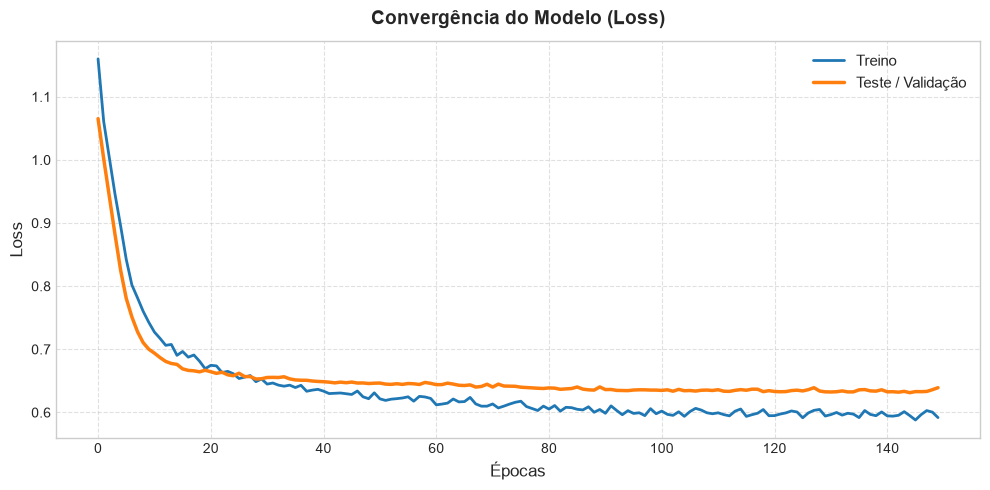

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Treino', linewidth=2)
plt.plot(test_losses, label='Teste / Validação', linewidth=2.5)

plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Convergência do Modelo (Loss)', fontsize=14, fontweight='bold', pad=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 10) Conclusões 

### 🔬 1. Análise Técnica

* **Recall da Classe Minoritária ($89\%$ a $93\%$):** O modelo se provou um excelente "detector" de potenciais clientes. No threshold de $0.35$, ele capta **$93\%$** dos clientes inclinados a assinar o depósito a prazo. Ao elevar o threshold para $0.50$, o recall se mantém muito elevado em **$89\%$**.
* **Precision da Classe Minoritária ($33\%$ a $37\%$):** Como o `pos_weight` penalizou fortemente os erros na Loss, há um volume moderado de falsos positivos. A cada 3 ligações recomendadas pelo modelo, **1 cliente efetivamente converte**. Ajustar o threshold para $0.50$ eleva a precisão para $37\%$, reduzindo acionamentos desnecessários.
* **Impacto da Alteração do Threshold ($0.35 \rightarrow 0.50$):** O threshold de $0.35$ força um recall máximo ao custo de um volume maior de chamadas. Já o threshold de $0.50$ equilibra melhor as métricas, elevando a acurácia geral de **$77\%$ para $81\%$** e o F1-Score da classe de interesse de **$0.48$ para $0.52$**.

---

### 💼 2. Análise de Negócio & Simulação de Cenários

Para mensurar o impacto real no banco, transformamos os resultados das métricas em **retorno financeiro (€) e eficiência operacional**.

> **Premissas para a simulação:**
> * **Base total de teste:** $9.043$ clientes.
> * **Volume real de conversores:** $1.058$ clientes ($11,7\%$).
> * **Custo estimado por ligação telefônica:** **€ 5,00**
> * **Lucro médio estimado por depósito convertido:** **€ 100,00**

---

#### 📊 Comparação de Cenários

| Métrica / Cenário | 1. Sem Modelo (Ligar para Todos) | 2. Modelo (Threshold = 0.35) | 3. Modelo (Threshold = 0.50) |
| --- | --- | --- | --- |
| **Volume de Ligações** | $9.043$ ($100\%$) | $2.980$ ($33,0\%$) | **$2.545$ ($28,1\%$)** |
| **Clientes Convertidos (Recall)** | $1.058$ ($100\%$) | **$984$ ($93,0\%$)** | **$942$ ($89,0\%$)** |
| **Taxa de Eficiência (Precision)** | $11,7\%$ | $33,0\%$ | **$37,0\%$** |
| **Custo de Telemarketing** | € 45.215,00 | **€ 14.900,00** | **€ 12.725,00** |
| **Receita Bruta Gerada** | € 105.800,00 | **€ 98.400,00** | **€ 94.200,00** |
| **Resultado Líquido (Lucro - Custo)** | **€ 60.585,00** | **€ 83.500,00** | **€ 81.475,00** |
| **Aumento no Lucro vs. Sem Modelo** | Base | **$+37,8\%$ (+€ 22.915)** | **$+34,5\%$ (+€ 20.890)** |

---

#### 💡 Principais Conclusões 

1. **Redução Acentuada de Custos Operacionais:** Em ambos os cenários com modelo, o banco economiza mais de **€ 30.000 em despesas de telemarketing** (redução de até $71,9\%$ no volume de chamadas em relação à abordagem sem modelo).
2. **Maximização do Lucro Líquido:** A estratégia inteligente de filtragem eleva o retorno líquido final da campanha de **€ 60,5 mil para até € 83,5 mil** (um ganho financeiro de **$+37,8\%$**).
3. **Tomada de Decisão Condicional (Estratégia de Negócio):**
* **Cenário A — Capacidade Excedente no Call Center (Threshold = 0.35):** Prioriza a receita absoluta. Captura $93\%$ dos conversores e atinge o lucro líquido máximo (€ 83.500).
* **Cenário B — Equipe de Vendas Enxuta / Foco em Experiência do Cliente (Threshold = 0.50):** Corta **435 ligações excedentes** em relação ao threshold $0.35$, economiza € 2.175 operacionais e eleva a precisão das chamadas para $37\%$, com um impacto mínimo no lucro final (€ 81.475).